# Bayesian network search modelling

Goal: find best combination of activities to find a missing person, measured by maximizing probability of detection

In [28]:
import pandas as pd
from math import prod
import random
pd.set_option('display.max_rows',20)
import time
import bn
import networkx as nx
import matplotlib.pyplot as plt

Set a random seed manually for verification in comparison with other methods, e.g. Monte-Carlo or a more direct analytical approach

In [29]:
random.seed(17)

## Activities

Key parameters:
* the number of activities (e.g. "search field")
* the maximum number of times each activity can be perforpartial
* proability of missing the person even though they are detectable, representing random error

In [30]:
num_activities = 4
max_tries = 3
prob_blink = 0.1

For readability, define a set of activities [a1...aN]

In [31]:
activities = [f'a{i+1}' for i in range(num_activities)]
print(activities)

['a1', 'a2', 'a3', 'a4']


Each activity has a type which determines how likely the object is to be occluded, given the global occlusion state.  You're more likely to see an occluded object by flying a circle around a target point than by flying over it once, for example.

In [32]:
activity_types = {}
for a in activities:
    activity_types[a] = random.sample(['along','mower','circle'],1)[0]
#activity_types = {'a1': 'circle', 'a2': 'mower', 'a3': 'mower'} # overwrite
print(activity_types)

{'a1': 'circle', 'a2': 'mower', 'a3': 'mower', 'a4': 'mower'}


## Bayesian network model

For illustrative purposes, construct the full Bayesian network that will be used to model the problem, with a series of intermediate nodes
* "occlusion", "appearance" and "region" represent how occluded the object is, how it looks compared to the background, and which region it is in
* "occ_a" is True if and only if the object is occluded from activity _a_
* "indis_a" is True if and only if the object is indistinguishable from the background in activity _a_
* "vis_a" is True if and only if the object is visible to activity _a_, i.e. it is neither occluded nor indistinguishable and is located in a region covered by _a_
* "num_a" is the number of times activity _a_ is performed, in the range 0 to `max_tries`
* "det_a" is True if and only if the object is detected by at least one execution of _a_
* "det_any" is True if and only if the object is detected by any of the activities undertaken



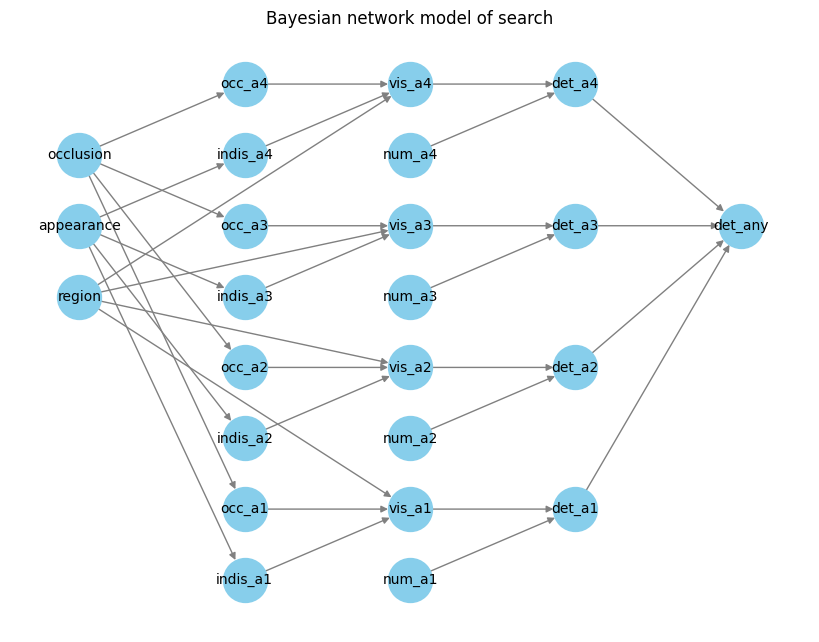

In [33]:
G = nx.DiGraph()
#G.add_nodes_from(["occlusion", "appearance", "region"])
pos = {'occlusion':(-1,1),
       'appearance':(-1,0),
       'region':(-1,-1),
       'det_any':(1,0)}
for i,a in enumerate(activities):
    G.add_edges_from([("occlusion", "occ_"+a), ("appearance", "indis_"+a),
                      ("region", "vis_"+a), ("occ_"+a, "vis_"+a),("indis_"+a,"vis_"+a),
                      ("vis_"+a,"det_"+a),("num_"+a,"det_"+a),("det_"+a,"det_any"),])
    pos['occ_'+a] = (-0.5,2*i-num_activities)
    pos['indis_'+a] = (-0.5,2*i-num_activities-1)
    pos['vis_'+a] = (0.0,2*i-num_activities)
    pos['num_'+a] = (0.0,2*i-num_activities-1)
    pos['det_'+a] = (0.5,2*i-num_activities)
plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, node_color="skyblue", node_size=1000, font_size=10, edge_color="gray")
plt.title("Bayesian network model of search")
plt.show()


In [34]:
start_time = time.time()
print(start_time)

1778585501.3588161


## Global states

Define a global occlusion state, capturing some of the mutual dependence of detection events.
* 'open' means not occlused it all
* 'partial' means medium, perhaps occluded from just one direction of view
* 'strong' means strongly occluded, perhaps from all but a single direction, say stuck in a cave

Define a prior probability for each and set up as a proability distribution in a Pandas dataframe.

In [35]:
pdf_occ = pd.DataFrame({'occlusion':['open','partial','strong'],
                        'prob' : [0.5,0.3,0.2]})#
bn.validate_pdf(pdf_occ)
pdf_occ

,occlusion,prob
0,open,0.5
1,partial,0.3
2,strong,0.2


Similarly define a global appearance state, representing whether or not the person is going to blend in with the surroundings or stand out.

In [36]:
pdf_app = pd.DataFrame({'appearance':['blend','neutral','obvious'],
                        'prob' : [0.2,0.4,0.4]})
bn.validate_pdf(pdf_app)
pdf_app

,appearance,prob
0,blend,0.2
1,neutral,0.4
2,obvious,0.4


In [37]:
num_regions = 2**num_activities
coverage = {}
for i in range(num_regions):
    if i>0:
        coverage[f'r{i}'] = [a if 2**j & i > 0 else "~"+a for j,a in enumerate(activities) ]
regions = [r for r in coverage.keys()]
print(regions)
print(coverage)

['r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'r13', 'r14', 'r15']
{'r1': ['a1', '~a2', '~a3', '~a4'], 'r2': ['~a1', 'a2', '~a3', '~a4'], 'r3': ['a1', 'a2', '~a3', '~a4'], 'r4': ['~a1', '~a2', 'a3', '~a4'], 'r5': ['a1', '~a2', 'a3', '~a4'], 'r6': ['~a1', 'a2', 'a3', '~a4'], 'r7': ['a1', 'a2', 'a3', '~a4'], 'r8': ['~a1', '~a2', '~a3', 'a4'], 'r9': ['a1', '~a2', '~a3', 'a4'], 'r10': ['~a1', 'a2', '~a3', 'a4'], 'r11': ['a1', 'a2', '~a3', 'a4'], 'r12': ['~a1', '~a2', 'a3', 'a4'], 'r13': ['a1', '~a2', 'a3', 'a4'], 'r14': ['~a1', 'a2', 'a3', 'a4'], 'r15': ['a1', 'a2', 'a3', 'a4']}


Finally define $2^{N_a}$ regions (where $N_a$ is the number of activities) representing the different overlaps between activities' respective footprints.

For example, `r1` has coverage `['a1', '~a2', '~a3', '~a4']` meaning is is that area covered only by activity `a1`, excluding any area covered by all other activities.

In [38]:
num_regions = 2**num_activities
coverage = {}
for i in range(num_regions):
    if i>0:
        coverage[f'r{i}'] = [a if 2**j & i > 0 else "~"+a for j,a in enumerate(activities) ]
regions = [r for r in coverage.keys()]
print(regions)
print(coverage)

['r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'r13', 'r14', 'r15']
{'r1': ['a1', '~a2', '~a3', '~a4'], 'r2': ['~a1', 'a2', '~a3', '~a4'], 'r3': ['a1', 'a2', '~a3', '~a4'], 'r4': ['~a1', '~a2', 'a3', '~a4'], 'r5': ['a1', '~a2', 'a3', '~a4'], 'r6': ['~a1', 'a2', 'a3', '~a4'], 'r7': ['a1', 'a2', 'a3', '~a4'], 'r8': ['~a1', '~a2', '~a3', 'a4'], 'r9': ['a1', '~a2', '~a3', 'a4'], 'r10': ['~a1', 'a2', '~a3', 'a4'], 'r11': ['a1', 'a2', '~a3', 'a4'], 'r12': ['~a1', '~a2', 'a3', 'a4'], 'r13': ['a1', '~a2', 'a3', 'a4'], 'r14': ['~a1', 'a2', 'a3', 'a4'], 'r15': ['a1', 'a2', 'a3', 'a4']}


Assign these random probabilities, in the absense of a real map and prior distribution.

In [39]:
region_probs = [0.75+random.random() for r in coverage]
region_probs = [p / sum(region_probs) for p in region_probs]
#region_probs = [0,0,0,0,0,0,1] # always vis to all
assert(sum(region_probs)==1)
pdf_region = pd.DataFrame({'region': coverage.keys(),
                           'prob': region_probs})
bn.validate_pdf(pdf_region)
pdf_region

,region,prob
0,r1,0.054142
1,r2,0.078956
2,r3,0.075733
3,r4,0.073502
4,r5,0.044795
5,r6,0.040461
6,r7,0.059065
7,r8,0.077929
8,r9,0.052202
9,r10,0.065181


Can combine these probabilities to get the joint distribution over the three global states

In [40]:
jpdf_global_states = bn.joint_pdf_independent(bn.joint_pdf_independent(pdf_app,pdf_occ),pdf_region)
bn.validate_pdf(jpdf_global_states)
jpdf_global_states

,appearance,occlusion,region,prob
0,blend,open,r1,0.005414
1,blend,open,r2,0.007896
2,blend,open,r3,0.007573
3,blend,open,r4,0.007350
4,blend,open,r5,0.004480
...,...,...,...,...
130,obvious,strong,r11,0.004447
131,obvious,strong,r12,0.006651
132,obvious,strong,r13,0.007063
133,obvious,strong,r14,0.004798


## Visibility models

Define the conditional probability of being indistinguishable in any given activity, given the appearance state

In [41]:
cpdf_indis_a_given_app = pd.DataFrame({'indis_a':[True,True,True,False,False,False],
                                       '|appearance':['blend','neutral','obvious','blend','neutral','obvious'],
                                       'prob' : [0.9,0.5,0.1,0.1,0.5,0.9]})
bn.validate_cpdf(cpdf_indis_a_given_app)
cpdf_indis_a_given_app

,indis_a,|appearance,prob
0,True,blend,0.9
1,True,neutral,0.5
2,True,obvious,0.1
3,False,blend,0.1
4,False,neutral,0.5
5,False,obvious,0.9


_Option: turn off distinguishability/blending_

In [42]:
turn_off_distinguishability = False
if turn_off_distinguishability:
    cpdf_indis_a_given_app = pd.DataFrame({'indis_a':[True,True,True,False,False,False],
                                        '|appearance':['blend','med','obvious','blend','partial','obvious'],
                                        'prob' : [0,0,0,1,1,1]})
    bn.validate_cpdf(cpdf_indis_a_given_app)
    cpdf_indis_a_given_app

For each activity type, we can define the conditional probability of occlusion to an activity of that type, given the global occlusion state.

In [43]:
cpdf_occ_a_given_occ = {'circle':pd.DataFrame({'occ_a':[True,True,True,False,False,False],
                                               '|occlusion':['strong','partial','open','strong','partial','open'],
                                               'prob' : [0.5,0.3,0.1,0.5,0.7,0.9]}),
                        'mower':pd.DataFrame({'occ_a':[True,True,True,False,False,False],
                                               '|occlusion':['strong','partial','open','strong','partial','open'],
                                               'prob' : [0.7,0.5,0.3,0.3,0.5,0.7]}),
                        'along':pd.DataFrame({'occ_a':[True,True,True,False,False,False],
                                               '|occlusion':['strong','partial','open','strong','partial','open'],
                                               'prob' : [0.9,0.7,0.5,0.1,0.3,0.5]}),
}
for k in cpdf_occ_a_given_occ:
    bn.validate_cpdf(cpdf_occ_a_given_occ[k])
cpdf_occ_a_given_occ

{'circle':    occ_a |occlusion  prob
 0   True     strong   0.5
 1   True    partial   0.3
 2   True       open   0.1
 3  False     strong   0.5
 4  False    partial   0.7
 5  False       open   0.9,
 'mower':    occ_a |occlusion  prob
 0   True     strong   0.7
 1   True    partial   0.5
 2   True       open   0.3
 3  False     strong   0.3
 4  False    partial   0.5
 5  False       open   0.7,
 'along':    occ_a |occlusion  prob
 0   True     strong   0.9
 1   True    partial   0.7
 2   True       open   0.5
 3  False     strong   0.1
 4  False    partial   0.3
 5  False       open   0.5}

_Option: turn off occlusion altogether_

In [44]:
turn_off_occlusion = False
if turn_off_occlusion:
    cpdf_occ_a_given_occ = {'circle':pd.DataFrame({'occ_a':[True,True,True,False,False,False],
                                                '|occlusion':['hard','med','open','hard','med','open'],
                                                'prob' : [0.,0.,0.,1.0,1.0,1.0]}),
                            'mower':pd.DataFrame({'occ_a':[True,True,True,False,False,False],
                                                '|occlusion':['hard','med','open','hard','med','open'],
                                                'prob' : [0.,0.,0.,1.0,1.0,1.0]}),
                            'along':pd.DataFrame({'occ_a':[True,True,True,False,False,False],
                                                '|occlusion':['hard','med','open','hard','med','open'],
                                                'prob' : [0.,0.,0.,1.0,1.0,1.0]}),
    }
    for k in cpdf_occ_a_given_occ:
        bn.validate_cpdf(cpdf_occ_a_given_occ[k])
    cpdf_occ_a_given_occ

## Detection model

For each activity, use the conditional probabilities of occlusion and indistiguishability to find the joint distribution over all those events and the global states.

In [45]:
jpdf_model = jpdf_global_states
for a in activities:
    # extract the relevant conditional model of occlusion
    this_occ_cpdf = cpdf_occ_a_given_occ[activity_types[a]].rename(columns={'occ_a':'occ_'+a})
    jpdf_model = bn.joint_pdf_dependent(jpdf_model,this_occ_cpdf)
    # and of indistunguishability
    this_ind_cpdf = cpdf_indis_a_given_app.rename(columns={'indis_a':'indis_'+a})
    jpdf_model = bn.joint_pdf_dependent(jpdf_model,this_ind_cpdf)
bn.validate_pdf(jpdf_model)
jpdf_model

,indis_a4,occ_a4,indis_a3,occ_a3,indis_a2,occ_a2,indis_a1,occ_a1,appearance,occlusion,region,prob
0,True,True,True,True,True,True,True,True,blend,open,r1,0.000010
1,True,True,True,True,True,True,True,True,blend,open,r2,0.000014
2,True,True,True,True,True,True,True,True,blend,open,r3,0.000013
3,True,True,True,True,True,True,True,True,blend,open,r4,0.000013
4,True,True,True,True,True,True,True,True,blend,open,r5,0.000008
...,...,...,...,...,...,...,...,...,...,...,...,...
34555,False,False,False,False,False,False,False,False,obvious,strong,r11,0.000039
34556,False,False,False,False,False,False,False,False,obvious,strong,r12,0.000059
34557,False,False,False,False,False,False,False,False,obvious,strong,r13,0.000063
34558,False,False,False,False,False,False,False,False,obvious,strong,r14,0.000042


Now determine the distribution of visibility, constructing on the go the conditional probability of visibility to each action given region, occlusion and indistinguishability.  The object is visible to activity _a_ if and only if it is not occluded from _a_, not indistinguishable to _a_, and lies in a region covered by _a_.

In [46]:
jpdf_model3 = jpdf_model
cpdf_vis_a = {}
for a in activities:
    print('Activity ',a)
    cpdf_vis_a[a] = pd.DataFrame({},columns=['vis_'+a,'|region','|occ_'+a,'|indis_'+a])
    for r in regions:
        for occ_a in [True,False]:
            for indis_a in [True,False]:
                prob_true = 0.0
                if occ_a==False:
                    if indis_a==False:
                        if a in coverage[r]:
                            prob_true = 1.0
                new_rows = pd.DataFrame({'vis_'+a:[True,False],
                                         'prob':[prob_true,1-prob_true]})
                new_rows['|occ_'+a] = occ_a
                new_rows['|indis_'+a] = indis_a
                new_rows['|region'] = r
                cpdf_vis_a[a] = pd.concat((cpdf_vis_a[a],new_rows))
    bn.validate_cpdf(cpdf_vis_a[a])
    print('Conditional distribution is ',cpdf_vis_a[a].shape)
    jpdf_model3 = bn.joint_pdf_dependent(jpdf_model3,cpdf_vis_a[a])
    print('Model is ', jpdf_model3.shape)          
bn.validate_pdf(jpdf_model3)
jpdf_model3

Activity  a1
Conditional distribution is  (120, 5)
Model is  (34560, 13)
Activity  a2
Conditional distribution is  (120, 5)
Model is  (34560, 14)
Activity  a3
Conditional distribution is  (120, 5)
Model is  (34560, 15)
Activity  a4
Conditional distribution is  (120, 5)
Model is  (34560, 16)


,vis_a4,vis_a3,vis_a2,vis_a1,indis_a4,occ_a4,indis_a3,occ_a3,indis_a2,occ_a2,indis_a1,occ_a1,appearance,occlusion,region,prob
55,True,True,True,True,False,False,False,False,False,False,False,False,blend,open,r15,2.810885e-07
57,True,True,True,True,False,False,False,False,False,False,False,False,blend,partial,r15,4.780416e-08
59,True,True,True,True,False,False,False,False,False,False,False,False,blend,strong,r15,4.917000e-09
61,True,True,True,True,False,False,False,False,False,False,False,False,neutral,open,r15,3.513606e-04
63,True,True,True,True,False,False,False,False,False,False,False,False,neutral,partial,r15,5.975520e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69096,False,False,False,False,False,False,False,False,False,False,False,True,neutral,partial,r1,1.522732e-05
69099,False,False,False,False,False,False,False,False,False,False,False,True,neutral,strong,r1,3.654556e-06
69102,False,False,False,False,False,False,False,False,False,False,False,True,obvious,open,r1,2.436829e-04
69105,False,False,False,False,False,False,False,False,False,False,False,True,obvious,partial,r1,1.598503e-04


Marginalize out the states for occlusion and indistinguishability for each activity - they have been used to determine the visibility states, and are nuisance variables for the rest.  This will shrink the model a lot.

In [47]:
jpdf_model3a = bn.get_marginal_pdf(jpdf_model3,['appearance','region','occlusion'] + ['vis_'+a for a in activities])
bn.validate_pdf(jpdf_model3a)
jpdf_model3a

,appearance,region,occlusion,vis_a1,vis_a2,vis_a3,vis_a4,prob
0,blend,r1,open,False,False,False,False,0.004927
1,blend,r1,open,True,False,False,False,0.000487
2,blend,r1,partial,False,False,False,False,0.003021
3,blend,r1,partial,True,False,False,False,0.000227
4,blend,r1,strong,False,False,False,False,0.002057
...,...,...,...,...,...,...,...,...
715,obvious,r9,partial,True,False,False,True,0.001776
716,obvious,r9,strong,False,False,False,False,0.001677
717,obvious,r9,strong,False,False,False,True,0.000620
718,obvious,r9,strong,True,False,False,False,0.001372


To explore different policies, i.e. combnations of activities, introduce the numbers of times each activity is performed as additional variables.  We have to assign them proabilities, done with the following distribution, but of course these are fixed decisions, so they will be take out again later as conditional variables.

_This is necessary because the modeling utility can only combine a conditional probability into a joint, not two conditionals together.  Perhaps some future iteration would remove the need to do this._

In [48]:
num_tries = [i for i in range(max_tries+1)]
prob_tries = [1/len(num_tries) for i in num_tries]
pdf_tries = pd.DataFrame({'num_a':num_tries,
                          'prob': prob_tries})
bn.validate_pdf(pdf_tries)
pdf_tries

,num_a,prob
0,0,0.25
1,1,0.25
2,2,0.25
3,3,0.25


Using the random miss probability, construct a general conditional probability of detecting something by some activity given its visibility state and the number of tries.

In [49]:
cpdf_det_a_given_vis_a_num_a = pd.merge(pd.DataFrame({'det_a':[True,False]}),
                                        pd.DataFrame({'|vis_a':[True,False]}),how='cross')
cpdf_det_a_given_vis_a_num_a = pd.merge(cpdf_det_a_given_vis_a_num_a,
                                        pd.DataFrame({'|num_a':[i for i in range(max_tries+1)]}),how='cross')
cpdf_det_a_given_vis_a_num_a['prob'] = 0.0
def cond_prob_det(r,prob_blink=prob_blink):
    prob_true = 0.0
    if r['|vis_a']==True:
        if r['|num_a']>0:
            prob_true = (1-prob_blink**r['|num_a'])
    if r['det_a']==True:
        return prob_true
    else:
        return 1-prob_true
cpdf_det_a_given_vis_a_num_a['prob'] = cpdf_det_a_given_vis_a_num_a.apply(cond_prob_det,axis=1)
bn.validate_cpdf(cpdf_det_a_given_vis_a_num_a)
cpdf_det_a_given_vis_a_num_a

,det_a,|vis_a,|num_a,prob
0,True,True,0,0.000
1,True,True,1,0.900
2,True,True,2,0.990
3,True,True,3,0.999
4,True,False,0,0.000
5,True,False,1,0.000
6,True,False,2,0.000
7,True,False,3,0.000
8,False,True,0,1.000
9,False,True,1,0.100


Now use this activity by activity to determine the joint distribution over detection, attempts, visibility, and the global states.  This is where the model gets biggest.

In [50]:
jpdf_model4 = jpdf_model3a
for a in activities:
    this_tries_pdf = pdf_tries.rename(columns={'num_a':'num_'+a})
    jpdf_model4 = bn.joint_pdf_independent(jpdf_model4,this_tries_pdf)
    this_det_cpdf = cpdf_det_a_given_vis_a_num_a.rename(columns={'|num_a':'|num_'+a,
                                                                '|vis_a':'|vis_'+a,
                                                                'det_a':'det_'+a})
    jpdf_model4 = bn.joint_pdf_dependent(jpdf_model4,this_det_cpdf)
bn.validate_pdf(jpdf_model4)
jpdf_model4

,det_a4,det_a3,det_a2,det_a1,appearance,region,occlusion,vis_a1,vis_a2,vis_a3,vis_a4,num_a1,num_a2,num_a3,num_a4,prob
109,True,True,True,True,blend,r15,open,True,True,True,True,1,1,1,1,7.203990e-10
110,True,True,True,True,blend,r15,open,True,True,True,True,1,1,1,2,7.924389e-10
111,True,True,True,True,blend,r15,open,True,True,True,True,1,1,1,3,7.996429e-10
113,True,True,True,True,blend,r15,open,True,True,True,True,1,1,2,1,7.924389e-10
114,True,True,True,True,blend,r15,open,True,True,True,True,1,1,2,2,8.716828e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
724387,False,False,False,False,obvious,r9,strong,True,False,False,True,3,3,2,3,1.982048e-12
724388,False,False,False,False,obvious,r9,strong,True,False,False,True,3,3,3,0,1.982048e-09
724389,False,False,False,False,obvious,r9,strong,True,False,False,True,3,3,3,1,1.982048e-10
724390,False,False,False,False,obvious,r9,strong,True,False,False,True,3,3,3,2,1.982048e-11


Saving further proability modeling, we can identify those combinations with at least one detection using a simple logical "or" in the form of a summation.  Add a final column for the `det_any` state.

In [51]:
detect_cols = ['det_'+a for a in activities]
jpdf_model4['det_any']=jpdf_model4[detect_cols].sum(axis=1)>0
jpdf_model4

,det_a4,det_a3,det_a2,det_a1,appearance,region,occlusion,vis_a1,vis_a2,vis_a3,vis_a4,num_a1,num_a2,num_a3,num_a4,prob,det_any
109,True,True,True,True,blend,r15,open,True,True,True,True,1,1,1,1,7.203990e-10,True
110,True,True,True,True,blend,r15,open,True,True,True,True,1,1,1,2,7.924389e-10,True
111,True,True,True,True,blend,r15,open,True,True,True,True,1,1,1,3,7.996429e-10,True
113,True,True,True,True,blend,r15,open,True,True,True,True,1,1,2,1,7.924389e-10,True
114,True,True,True,True,blend,r15,open,True,True,True,True,1,1,2,2,8.716828e-10,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
724387,False,False,False,False,obvious,r9,strong,True,False,False,True,3,3,2,3,1.982048e-12,False
724388,False,False,False,False,obvious,r9,strong,True,False,False,True,3,3,3,0,1.982048e-09,False
724389,False,False,False,False,obvious,r9,strong,True,False,False,True,3,3,3,1,1.982048e-10,False
724390,False,False,False,False,obvious,r9,strong,True,False,False,True,3,3,3,2,1.982048e-11,False


## Results

Process the table to get the probability of detection given the numbers of attempts of each activity.

In [52]:
summary_table = bn.get_conditional_pdf(jpdf_model4,of=['det_any'],given=['num_'+a for a in activities])

Just grab the rows where `det_any` was true and show the policies in order of descending probability.

In [53]:
summary_table[summary_table['det_any']==True].drop('det_any',axis=1).sort_values(['prob'],ascending=[False])

,|num_a1,|num_a2,|num_a3,|num_a4,prob
510,3,3,3,3,0.529039
494,3,2,3,3,0.528350
506,3,3,2,3,0.528348
509,3,3,3,2,0.528289
446,2,3,3,3,0.528072
...,...,...,...,...,...
303,0,3,0,0,0.170678
287,0,2,0,0,0.169141
256,0,0,0,1,0.167600
259,0,0,1,0,0.157931


In [54]:
end_time = time.time()
print(f'Ran in {end_time - start_time:.1f} seconds')

Ran in 1.6 seconds
